# Smoking & Health Data Analysis

**Portfolio Project | Data Analyst**

This notebook explores a smoking and health dataset to uncover patterns across demographics, cholesterol, heart rate, and blood pressure.

### Project goals
- Clean and prepare the dataset for analysis
- Engineer useful health-related features
- Compare smokers vs non-smokers
- Build clear, presentation-ready visualizations
- Summarize insights in a portfolio-friendly format

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot styling
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["figure.facecolor"] = "white"

## 1) Load the data

The dataset includes basic demographic information and a few health indicators:
- age
- sex
- smoking status
- heart rate
- blood pressure
- cigarettes per day
- cholesterol

In [2]:
file_path = "smoking_health_data_final.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (3900, 7)


,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
0,54,male,yes,95,110/72,NaN,219.00
1,45,male,yes,64,121/72,NaN,248.00
2,58,male,yes,81,127.5/76,NaN,235.00
3,42,male,yes,90,122.5/80,NaN,225.00
4,42,male,yes,62,119/80,NaN,226.00


## 2) Initial data inspection

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nSummary statistics:")
display(df.describe(include="all"))

Column names:
['age', 'sex', 'current_smoker', 'heart_rate', 'blood_pressure', 'cigs_per_day', 'chol']

Data types:


,dtype
age,int64
sex,object
current_smoker,object
heart_rate,int64
blood_pressure,object
cigs_per_day,float64
chol,float64



Missing values:


,missing_values
age,0
sex,0
current_smoker,0
heart_rate,0
blood_pressure,0
cigs_per_day,14
chol,7



Summary statistics:


,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
count,"3,900.00",3900,3900,"3,900.00",3900,"3,886.00","3,893.00"
unique,NaN,2,2,NaN,2317,NaN,NaN
top,NaN,female,no,NaN,130/80,NaN,NaN
freq,NaN,2081,1968,NaN,18,NaN,NaN
mean,49.54,NaN,NaN,75.69,NaN,9.17,236.60
std,8.56,NaN,NaN,12.02,NaN,12.04,44.38
min,32.00,NaN,NaN,44.00,NaN,0.00,113.00
25%,42.00,NaN,NaN,68.00,NaN,0.00,206.00
50%,49.00,NaN,NaN,75.00,NaN,0.00,234.00
75%,56.00,NaN,NaN,82.00,NaN,20.00,263.00


## 3) Data cleaning and preparation

In this step:
- standardize text columns
- split blood pressure into systolic and diastolic values
- handle missing values
- create analysis-friendly categorical fields

In [4]:
# Standardize text fields
df["sex"] = df["sex"].astype(str).str.strip().str.lower().str.title()
df["current_smoker"] = df["current_smoker"].astype(str).str.strip().str.lower().str.title()

# Split blood pressure into numeric systolic and diastolic columns
bp_split = df["blood_pressure"].astype(str).str.split("/", expand=True)
df["systolic_bp"] = pd.to_numeric(bp_split[0], errors="coerce")
df["diastolic_bp"] = pd.to_numeric(bp_split[1], errors="coerce")

# Impute cigarettes/day with 0 for non-smokers if missing
df.loc[(df["current_smoker"] == "No") & (df["cigs_per_day"].isna()), "cigs_per_day"] = 0

# Fill remaining numeric missing values with median
numeric_fill_cols = ["cigs_per_day", "chol", "systolic_bp", "diastolic_bp"]
for col in numeric_fill_cols:
    df[col] = df[col].fillna(df[col].median())

# Smoking flag
df["smoker_flag"] = df["current_smoker"].map({"No": 0, "Yes": 1})

# Age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[20, 30, 40, 50, 60, 70, 80],
    labels=["21-30", "31-40", "41-50", "51-60", "61-70", "71-80"],
    include_lowest=True
)

# Cholesterol category
df["chol_category"] = pd.cut(
    df["chol"],
    bins=[0, 200, 239, np.inf],
    labels=["Desirable", "Borderline High", "High"]
)

display(df.head())

,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol,systolic_bp,diastolic_bp,smoker_flag,age_group,chol_category
0,54,Male,Yes,95,110/72,0.00,219.00,110.00,72.00,1,51-60,Borderline High
1,45,Male,Yes,64,121/72,0.00,248.00,121.00,72.00,1,41-50,High
2,58,Male,Yes,81,127.5/76,0.00,235.00,127.50,76.00,1,51-60,Borderline High
3,42,Male,Yes,90,122.5/80,0.00,225.00,122.50,80.00,1,41-50,Borderline High
4,42,Male,Yes,62,119/80,0.00,226.00,119.00,80.00,1,41-50,Borderline High


## 4) Feature engineering

In [5]:
# Additional blood pressure features
df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]
df["mean_arterial_pressure"] = (df["systolic_bp"] + 2 * df["diastolic_bp"]) / 3

# Simple portfolio-style risk score (not a medical diagnosis)
for col in ["cigs_per_day", "chol", "heart_rate", "systolic_bp"]:
    df[f"{col}_z"] = (df[col] - df[col].mean()) / df[col].std()

df["health_risk_score"] = (
    0.35 * df["cigs_per_day_z"] +
    0.25 * df["chol_z"] +
    0.20 * df["heart_rate_z"] +
    0.20 * df["systolic_bp_z"]
)

df[["age", "sex", "current_smoker", "cigs_per_day", "chol", "heart_rate",
    "systolic_bp", "diastolic_bp", "health_risk_score"]].head()

,age,sex,current_smoker,cigs_per_day,chol,heart_rate,systolic_bp,diastolic_bp,health_risk_score
0,54,Male,Yes,0.00,219.00,95,110.00,72.00,-0.25
1,45,Male,Yes,0.00,248.00,64,121.00,72.00,-0.50
2,58,Male,Yes,0.00,235.00,81,127.50,76.00,-0.23
3,42,Male,Yes,0.00,225.00,90,122.50,80.00,-0.18
4,42,Male,Yes,0.00,226.00,62,119.00,80.00,-0.68


## 5) Executive summary table

In [6]:
summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Average age",
        "Smoker rate",
        "Average cigarettes/day",
        "Average cholesterol",
        "Average heart rate",
        "Average systolic BP",
        "Average diastolic BP"
    ],
    "Value": [
        len(df),
        round(df["age"].mean(), 1),
        f"{df['smoker_flag'].mean():.1%}",
        round(df["cigs_per_day"].mean(), 1),
        round(df["chol"].mean(), 1),
        round(df["heart_rate"].mean(), 1),
        round(df["systolic_bp"].mean(), 1),
        round(df["diastolic_bp"].mean(), 1),
    ]
})

display(summary)

,Metric,Value
0,Total records,3900
1,Average age,49.50
2,Smoker rate,49.5%
3,Average cigarettes/day,9.10
4,Average cholesterol,236.60
5,Average heart rate,75.70
6,Average systolic BP,132.40
7,Average diastolic BP,83.00


## 6) Visual analysis

The charts below are designed to be easy to present in a portfolio:
- simple labels
- clean styling
- business-style titles
- clear comparisons between groups

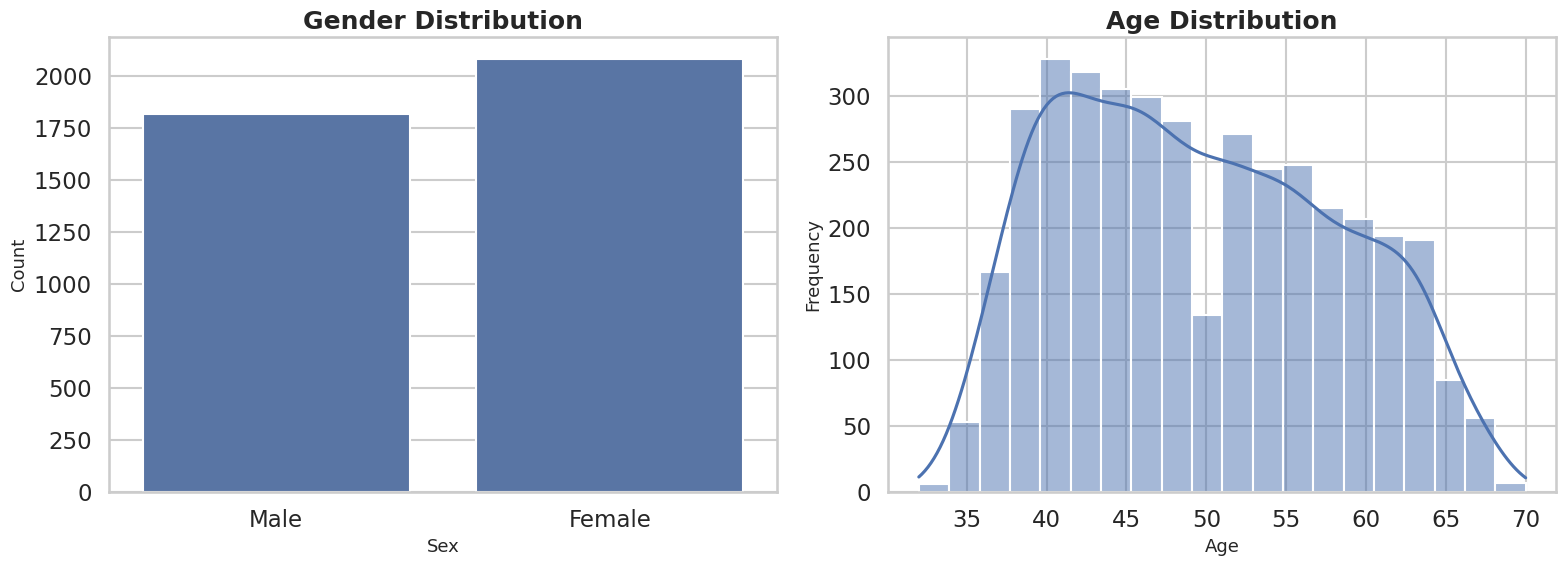

In [7]:
# 1. Demographic overview
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x="sex", ax=axes[0])
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[1])
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Insight:** This view gives a quick demographic snapshot of the dataset before comparing health patterns.

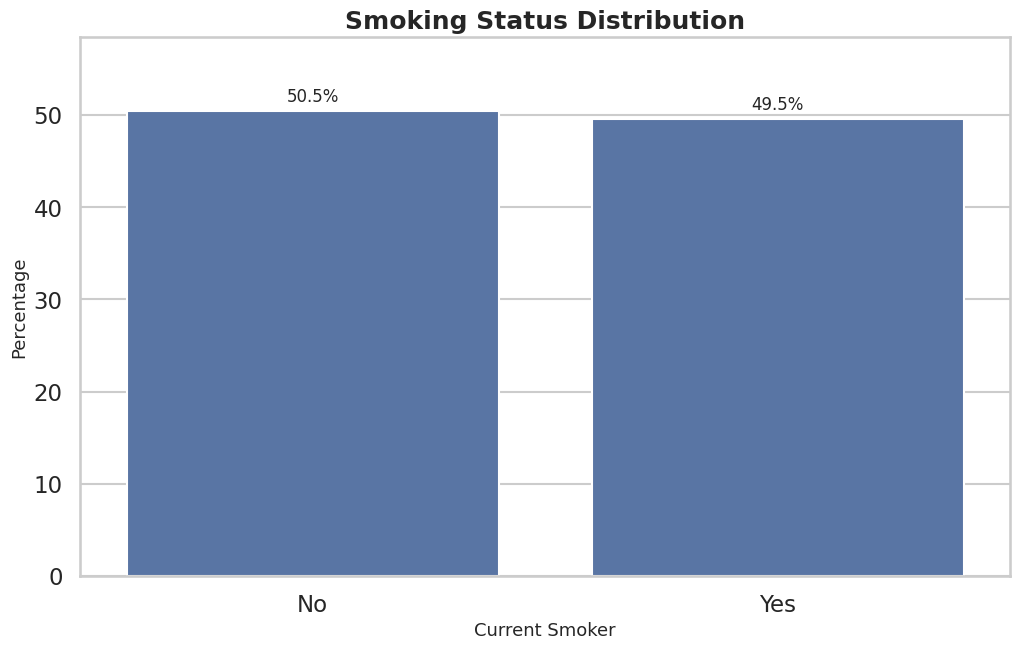

In [8]:
# 2. Smoking status split
smoker_pct = (
    df["current_smoker"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

ax = sns.barplot(x=smoker_pct.index, y=smoker_pct.values)
ax.set_title("Smoking Status Distribution")
ax.set_xlabel("Current Smoker")
ax.set_ylabel("Percentage")

for i, v in enumerate(smoker_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)

plt.ylim(0, max(smoker_pct.values) + 8)
plt.show()

**Insight:** This chart highlights the balance between smokers and non-smokers in the sample.

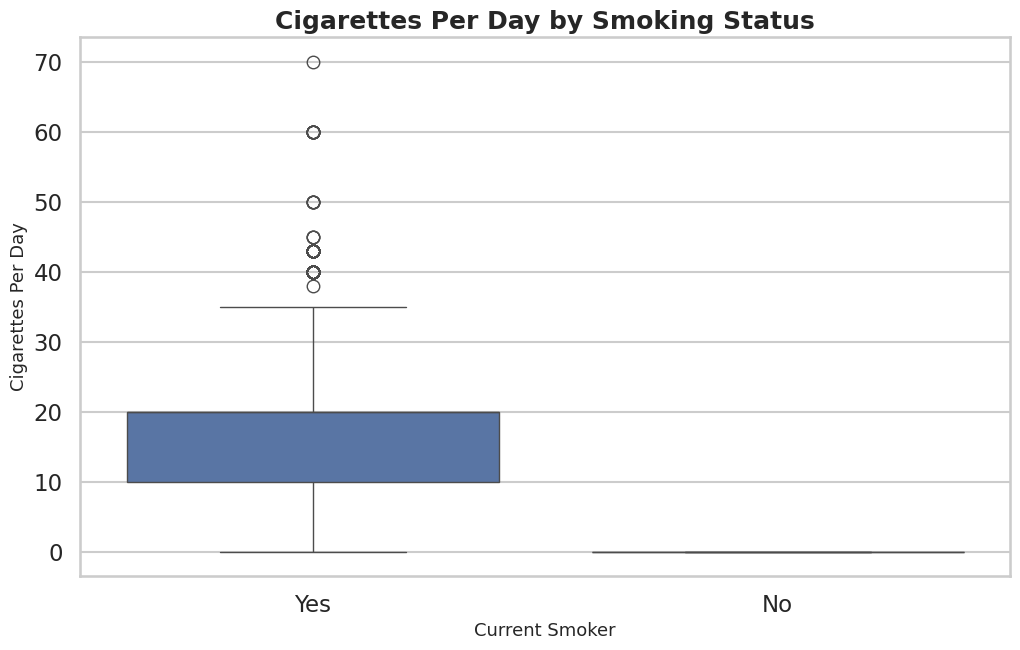

In [9]:
# 3. Cigarettes per day among smoking groups
sns.boxplot(data=df, x="current_smoker", y="cigs_per_day")
plt.title("Cigarettes Per Day by Smoking Status")
plt.xlabel("Current Smoker")
plt.ylabel("Cigarettes Per Day")
plt.show()

**Insight:** The boxplot shows how cigarette consumption varies and whether the distribution is skewed by heavy smokers.

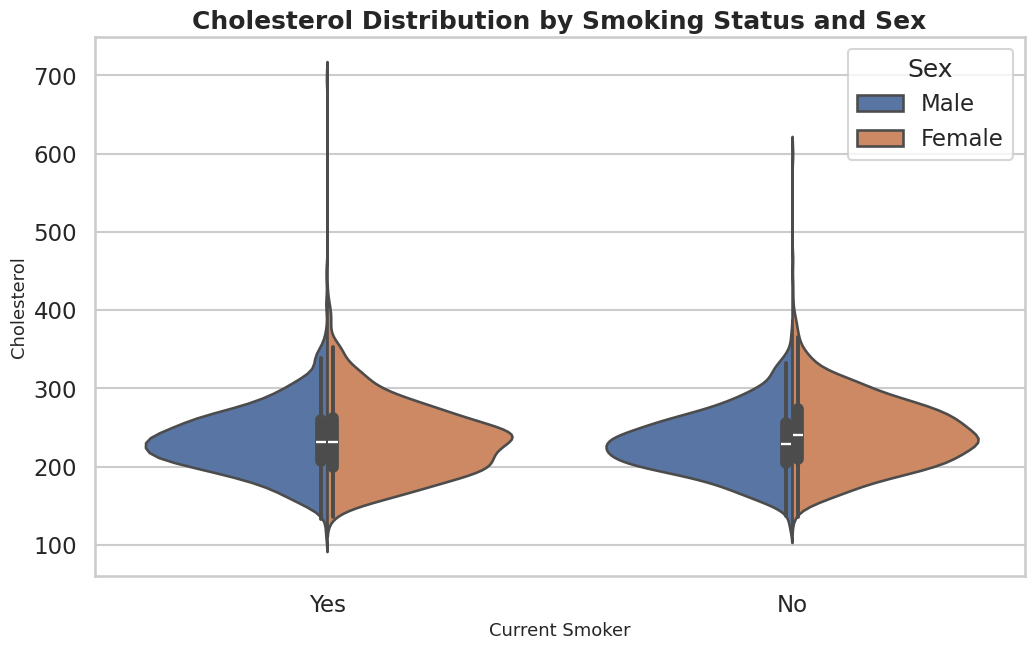

In [10]:
# 4. Cholesterol by smoking status and sex
sns.violinplot(data=df, x="current_smoker", y="chol", hue="sex", split=True)
plt.title("Cholesterol Distribution by Smoking Status and Sex")
plt.xlabel("Current Smoker")
plt.ylabel("Cholesterol")
plt.legend(title="Sex")
plt.show()

**Insight:** This view helps compare cholesterol patterns across both smoking status and gender.

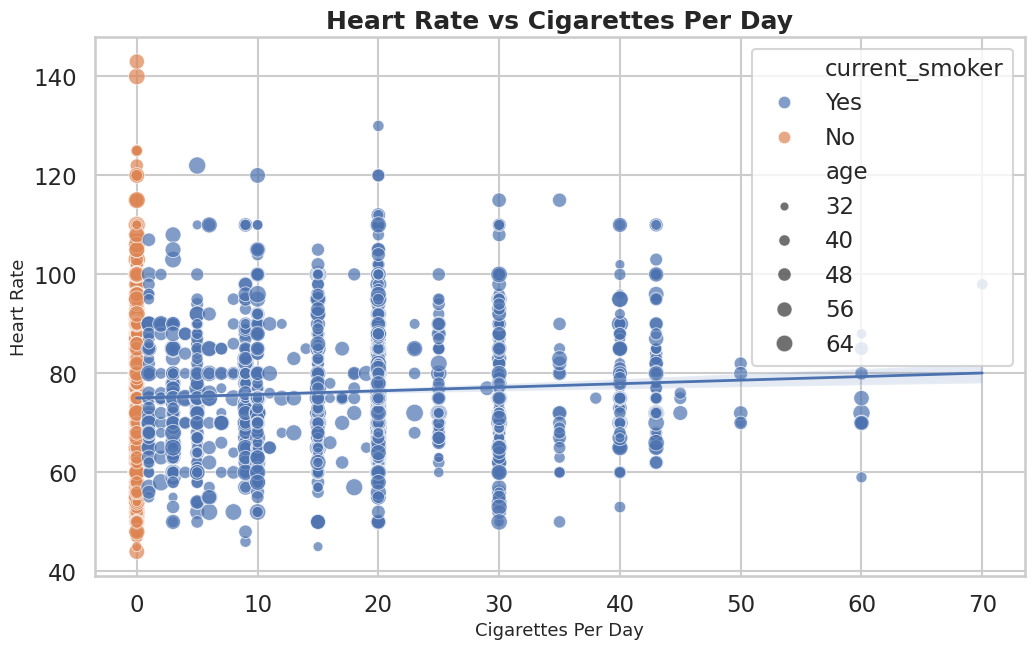

In [11]:
# 5. Heart rate vs cigarettes per day
sns.scatterplot(
    data=df,
    x="cigs_per_day",
    y="heart_rate",
    hue="current_smoker",
    size="age",
    alpha=0.7
)
sns.regplot(
    data=df,
    x="cigs_per_day",
    y="heart_rate",
    scatter=False,
    line_kws={"linewidth": 2}
)
plt.title("Heart Rate vs Cigarettes Per Day")
plt.xlabel("Cigarettes Per Day")
plt.ylabel("Heart Rate")
plt.show()

**Insight:** This chart explores whether higher cigarette use aligns with higher heart rate.

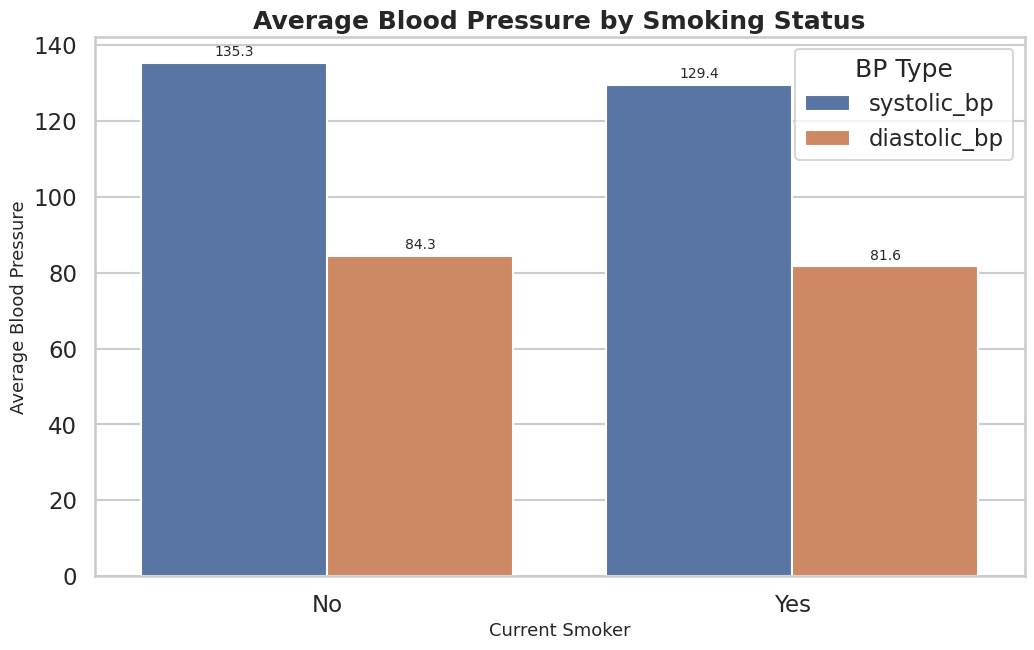

In [12]:
# 6. Average blood pressure by smoking status
bp_means = (
    df.groupby("current_smoker")[["systolic_bp", "diastolic_bp"]]
    .mean()
    .reset_index()
)

bp_long = bp_means.melt(
    id_vars="current_smoker",
    var_name="BP Type",
    value_name="Average Value"
)

ax = sns.barplot(data=bp_long, x="current_smoker", y="Average Value", hue="BP Type")
ax.set_title("Average Blood Pressure by Smoking Status")
ax.set_xlabel("Current Smoker")
ax.set_ylabel("Average Blood Pressure")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=10)

plt.show()

**Insight:** This gives a direct comparison of average systolic and diastolic blood pressure across smoking groups.

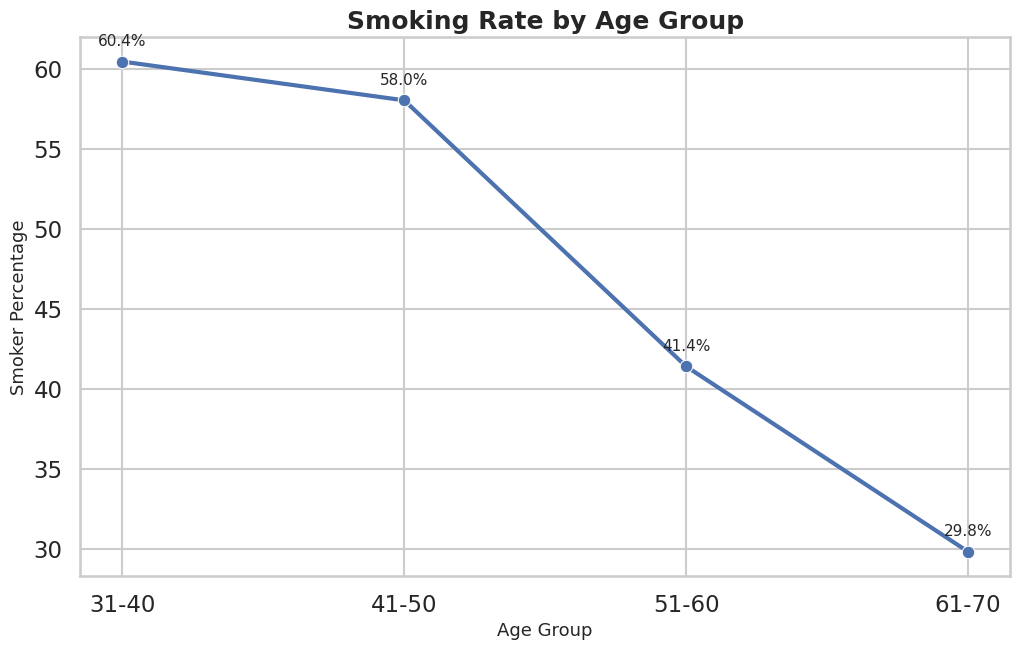

In [13]:
# 7. Smoking rate by age group
age_smoking = (
    df.groupby("age_group", observed=False)["smoker_flag"]
    .mean()
    .reset_index()
    .dropna()
)
age_smoking["smoker_pct"] = age_smoking["smoker_flag"] * 100

sns.lineplot(data=age_smoking, x="age_group", y="smoker_pct", marker="o", linewidth=3)
plt.title("Smoking Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Smoker Percentage")

for x, y in zip(age_smoking["age_group"], age_smoking["smoker_pct"]):
    plt.text(x, y + 1, f"{y:.1f}%", ha="center", fontsize=11)

plt.show()

**Insight:** Age segmentation helps reveal whether smoking behavior is concentrated in particular age bands.

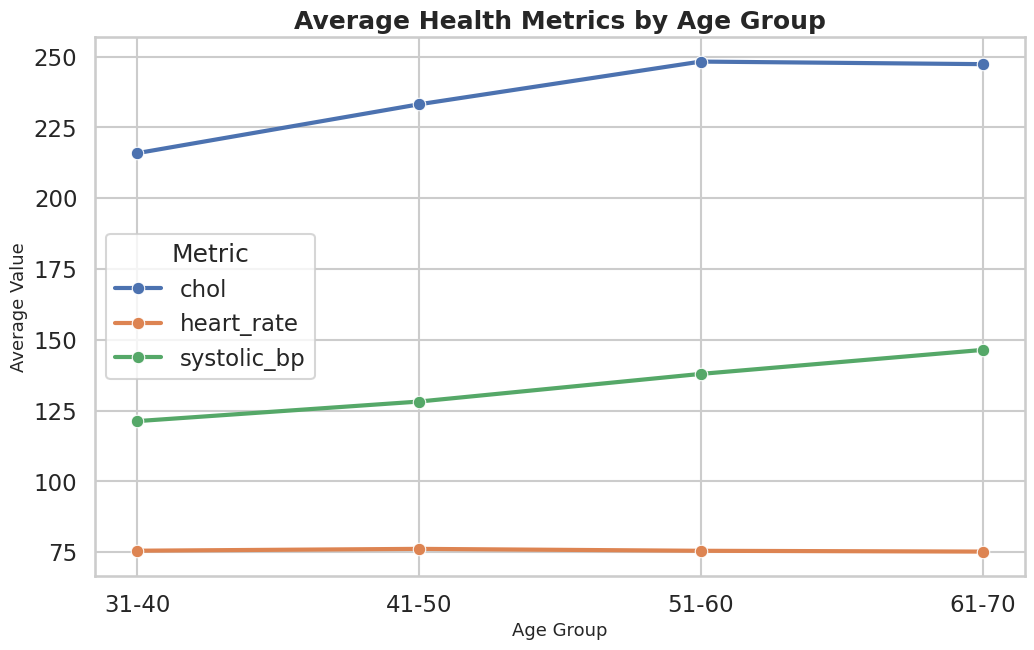

In [14]:
# 8. Average health metrics by age group
age_profile = (
    df.groupby("age_group", observed=False)[["chol", "heart_rate", "systolic_bp"]]
    .mean()
    .reset_index()
    .dropna()
)

age_profile_long = age_profile.melt(
    id_vars="age_group",
    var_name="Metric",
    value_name="Average Value"
)

sns.lineplot(data=age_profile_long, x="age_group", y="Average Value", hue="Metric", marker="o", linewidth=3)
plt.title("Average Health Metrics by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Value")
plt.show()

**Insight:** This chart compares how key health indicators move across age groups.

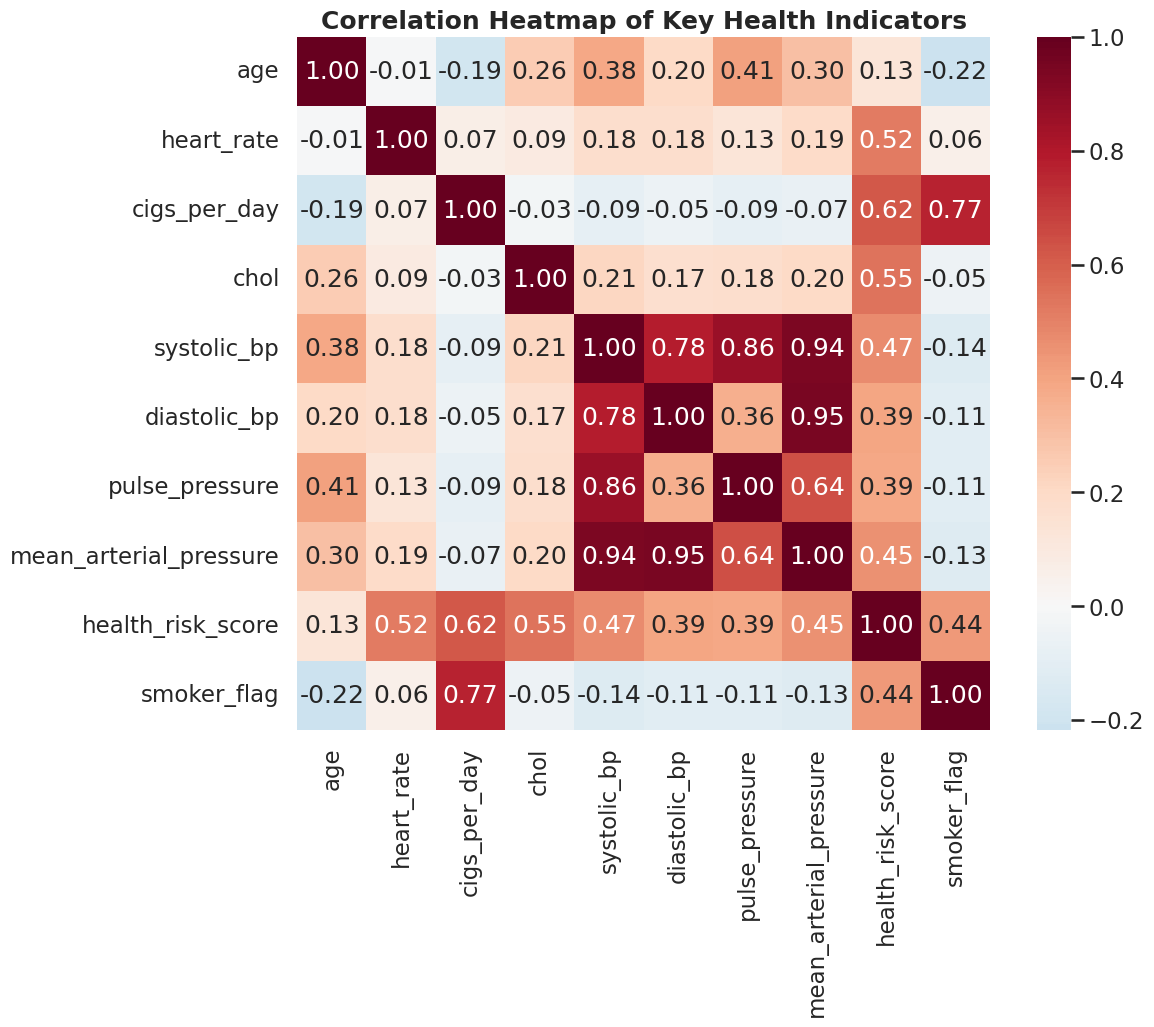

In [15]:
# 9. Correlation heatmap
corr_cols = [
    "age", "heart_rate", "cigs_per_day", "chol",
    "systolic_bp", "diastolic_bp", "pulse_pressure",
    "mean_arterial_pressure", "health_risk_score", "smoker_flag"
]
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="RdBu_r", square=True)
plt.title("Correlation Heatmap of Key Health Indicators")
plt.show()

**Insight:** The heatmap highlights the strongest relationships between smoking variables and health indicators.

## 7) Group comparisons and analytical operations

In [16]:
# Compare average metrics by smoking status
comparison = (
    df.groupby("current_smoker")[[
        "age", "cigs_per_day", "chol", "heart_rate",
        "systolic_bp", "diastolic_bp", "health_risk_score"
    ]]
    .mean()
    .round(2)
)

display(comparison)

,age,cigs_per_day,chol,heart_rate,systolic_bp,diastolic_bp,health_risk_score
current_smoker,,,,,,,
No,51.38,0.00,238.64,75.01,135.34,84.31,-0.24
Yes,47.66,18.44,234.51,76.38,129.39,81.64,0.24


current_smoker,No,Yes
chol_category,,
Desirable,46.10,53.90
Borderline High,50.90,49.10
High,52.20,47.80


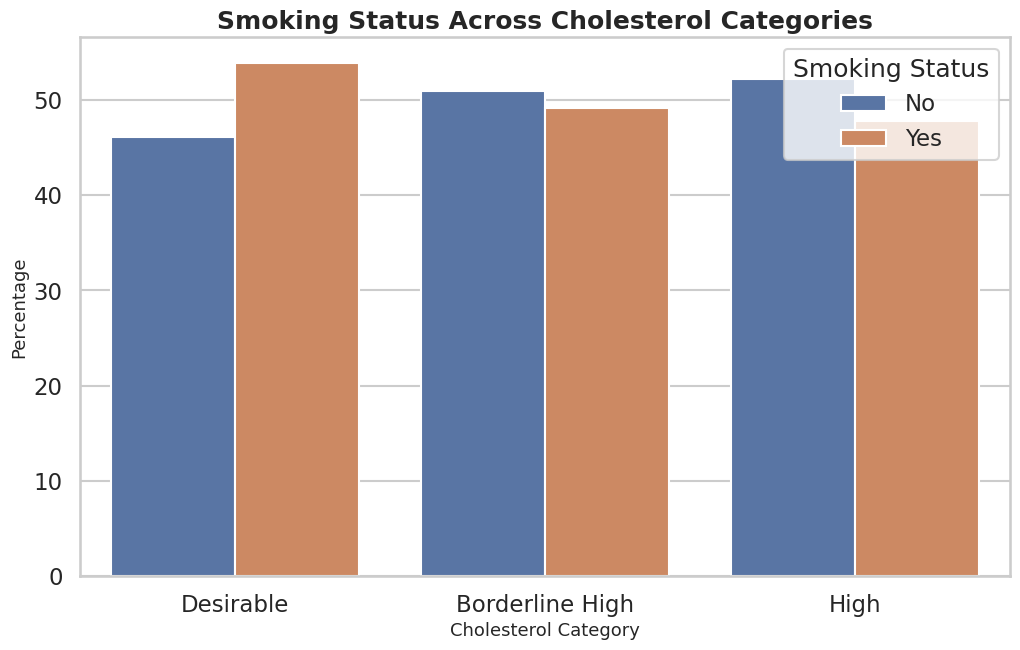

In [17]:
# Cholesterol category by smoking status
chol_cat = pd.crosstab(df["chol_category"], df["current_smoker"], normalize="index").mul(100).round(1)
display(chol_cat)

chol_cat_plot = chol_cat.reset_index().melt(
    id_vars="chol_category",
    var_name="Smoking Status",
    value_name="Percentage"
)

sns.barplot(data=chol_cat_plot, x="chol_category", y="Percentage", hue="Smoking Status")
plt.title("Smoking Status Across Cholesterol Categories")
plt.xlabel("Cholesterol Category")
plt.ylabel("Percentage")
plt.show()

current_smoker,No,Yes
risk_segment,,
High Risk,16.00,84.00
Other,59.10,40.90


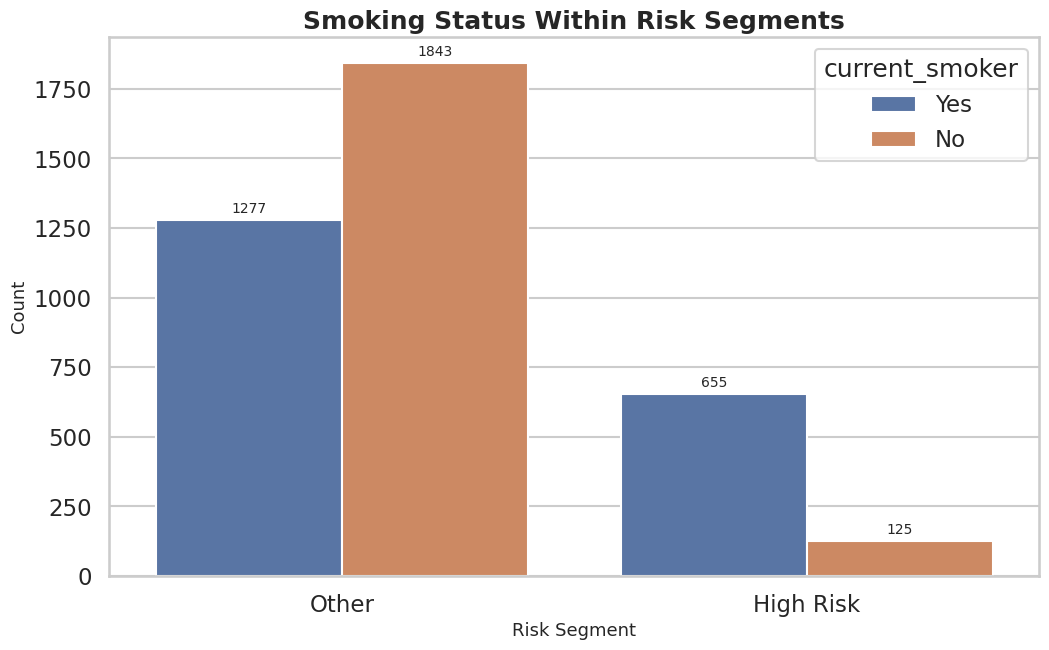

In [18]:
# High-risk segment analysis
threshold = df["health_risk_score"].quantile(0.80)
df["risk_segment"] = np.where(df["health_risk_score"] >= threshold, "High Risk", "Other")

risk_summary = pd.crosstab(df["risk_segment"], df["current_smoker"], normalize="index").mul(100).round(1)
display(risk_summary)

ax = sns.countplot(data=df, x="risk_segment", hue="current_smoker")
ax.set_title("Smoking Status Within Risk Segments")
ax.set_xlabel("Risk Segment")
ax.set_ylabel("Count")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.show()

## 8) Final insights

### Key takeaways
- The dataset can be transformed into a stronger analytical dataset by splitting blood pressure into numeric features.
- Smoking behavior can be compared directly against cholesterol, heart rate, and blood pressure.
- A simple engineered risk score helps identify higher-risk individuals for segmentation analysis.
- Age-based grouping improves storytelling and makes the analysis more business-friendly.
- Clean visual design makes the notebook suitable for a portfolio or interview presentation.

## 9) Optional export

Save the cleaned dataset so it can be reused in dashboards, SQL practice, or machine learning projects.

In [19]:
cleaned_file = "cleaned_smoking_health_data.csv"
df.to_csv(cleaned_file, index=False)
print(f"Cleaned dataset exported as: {cleaned_file}")

Cleaned dataset exported as: cleaned_smoking_health_data.csv
